# LAB 06: NHẬN DIỆN ẢNH (IMAGE DETECTION)

## Bài 1

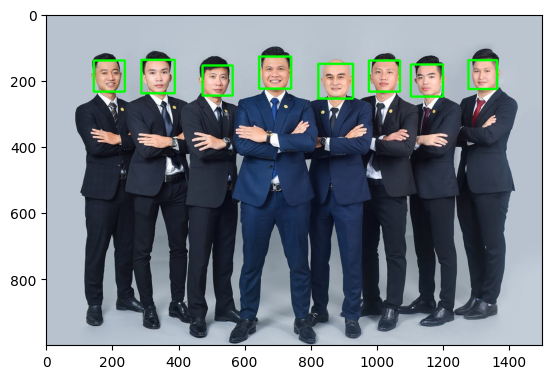

In [13]:
import cv2
import matplotlib.pyplot as Phat
img = cv2.imread('img.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

stop_data = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
found = stop_data.detectMultiScale(img_gray, minSize = (20, 20))
amount_found = len(found)

if amount_found != 0:
  for (x, y, width, height) in found:
    cv2.rectangle(img_rgb, (x, y), (x + height, y + width), (0, 255, 0), 5)

Phat.imshow(img_rgb)

## Bài 2

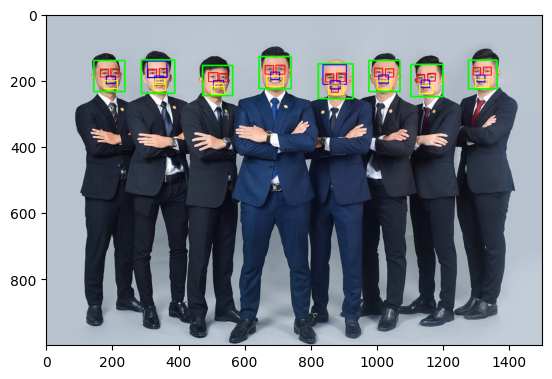

In [11]:
import cv2
import matplotlib.pyplot as Phat

img = cv2.imread('img.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('/content/haarcascade_eye.xml')
nose_cascade = cv2.CascadeClassifier('/content/haarcascade_mcs_nose.xml')
mouth_cascade = cv2.CascadeClassifier('/content/haarcascade_mcs_mouth.xml')

faces = face_cascade.detectMultiScale(img_gray, minSize=(20, 20))

for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)

    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_rgb[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)

    noses = nose_cascade.detectMultiScale(roi_gray)
    for (nx, ny, nw, nh) in noses:
        cv2.rectangle(roi_color, (nx, ny), (nx + nw, ny + nh), (0, 0, 255), 2)

    mouths = mouth_cascade.detectMultiScale(roi_gray)
    for (mx, my, mw, mh) in mouths:
        if my > h/2:
            cv2.rectangle(roi_color, (mx, my), (mx + mw, my + mh), (255, 255, 0), 2)

Phat.imshow(img_rgb)
